In [2]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 2.0 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.2 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.2 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.2 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.2 MB 1.2 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.2 MB 909.0 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.2 MB 909.0 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.2 MB 855.3 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.2 MB 855.3 kB/s eta 0:00:08
   -------- ------------------------------- 1.8/8.2 MB 795.9 kB/s eta 0:00:09
   ---------- 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, confusion_matrix

In [3]:
img = np.load(r"E:\Projects\archive\indianpinearray.npy")
gt = np.load(r"E:\Projects\archive\IPgt.npy")

print("Image shape :", img.shape)
print("Ground truth shape :", gt.shape)
print("Labels in ground truth :", np.unique(gt))

Image shape : (145, 145, 200)
Ground truth shape : (145, 145)
Labels in ground truth : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [4]:
# Step 4: Class names of Indian Pines (0 = background, no label)
class_names = ['Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn', 'Grass-pasture',
               'Grass-trees', 'Grass-pasture-mowed', 'Hay-windrowed', 'Oats',
               'Soybean-notill', 'Soybean-mintill', 'Soybean-clean', 'Wheat',
               'Woods', 'Buildings-Grass-Trees-Drives', 'Stone-Steel-Towers']

# Number of pixels in each class
for i in range(1, 17):
    print(i, class_names[i-1], ":", np.sum(gt == i))

1 Alfalfa : 46
2 Corn-notill : 1428
3 Corn-mintill : 830
4 Corn : 237
5 Grass-pasture : 483
6 Grass-trees : 730
7 Grass-pasture-mowed : 28
8 Hay-windrowed : 478
9 Oats : 20
10 Soybean-notill : 972
11 Soybean-mintill : 2455
12 Soybean-clean : 593
13 Wheat : 205
14 Woods : 1265
15 Buildings-Grass-Trees-Drives : 386
16 Stone-Steel-Towers : 93


In [9]:
# Custom colors: white for background (0) and 16 different colors for the classes
from matplotlib.colors import ListedColormap

colors = ['white'] + [plt.cm.tab20(i) for i in range(16)]
my_cmap = ListedColormap(colors)

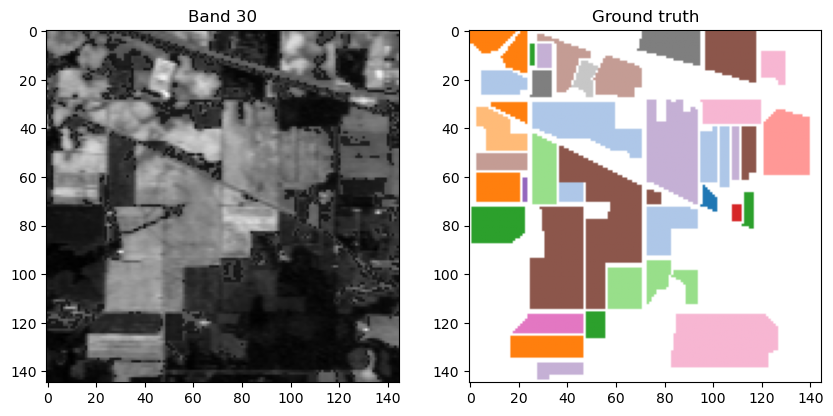

In [10]:
# Step 5: Look at one band and the ground truth map
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img[:, :, 30], cmap='gray')
ax[0].set_title('Band 30')

ax[1].imshow(gt, cmap=my_cmap, vmin=0, vmax=16)
ax[1].set_title('Ground truth')

plt.show()

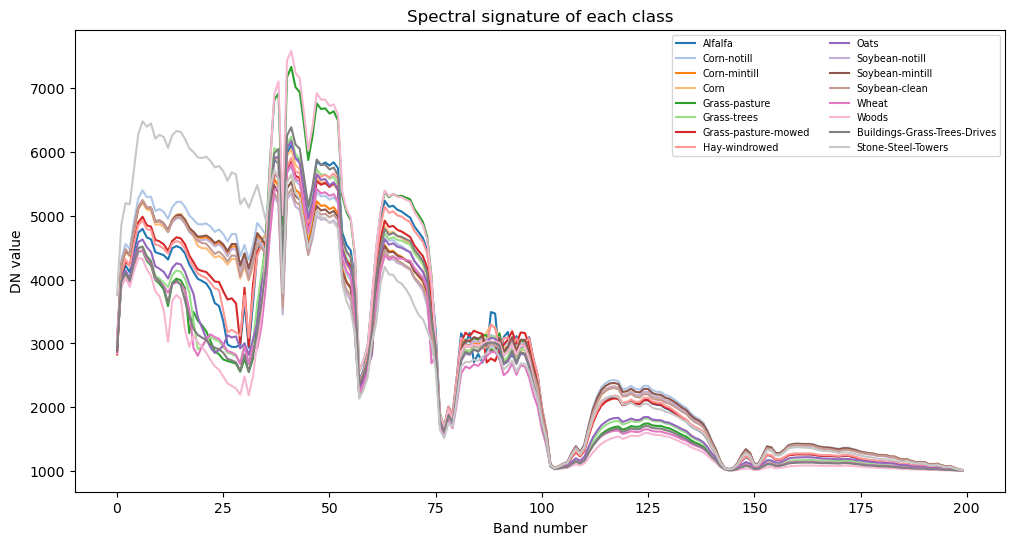

In [11]:
# Step 6: Spectral signature (mean spectrum) of each class
plt.figure(figsize=(12, 6))

for i in range(1, 17):
    mean_spectrum = img[gt == i].mean(axis=0)
    plt.plot(mean_spectrum, color=plt.cm.tab20(i-1), label=class_names[i-1])

plt.xlabel('Band number')
plt.ylabel('DN value')
plt.title('Spectral signature of each class')
plt.legend(fontsize=7, ncol=2)
plt.show()

In [12]:
# Step 7: Convert the image into a table (each pixel = one row, each band = one column)
X_all = img.reshape(-1, img.shape[2])
y_all = gt.reshape(-1)

# Keep only labelled pixels (remove background = 0)
X = X_all[y_all > 0]
y = y_all[y_all > 0]

print("X shape :", X.shape)
print("y shape :", y.shape)

X shape : (10249, 200)
y shape : (10249,)


In [13]:
# Step 8: Split into training and testing data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1, stratify=y)

print('X_train shape : ({0},{1})'.format(X_train.shape[0], X_train.shape[1]))
print('y_train shape : ({0},)'.format(y_train.shape[0]))
print('X_test shape : ({0},{1})'.format(X_test.shape[0], X_test.shape[1]))
print('y_test shape : ({0},)'.format(y_test.shape[0]))

X_train shape : (8199,200)
y_train shape : (8199,)
X_test shape : (2050,200)
y_test shape : (2050,)


In [14]:
# Step 9: Scale the data (needed for SVM)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [15]:
# Step 10: Random Forest model
rf = RandomForestClassifier(n_estimators=200, random_state=1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest accuracy :", accuracy_score(y_test, rf_pred))

Random Forest accuracy : 0.8824390243902439


In [16]:
# Step 11: SVM model
svm = SVC(kernel='rbf', C=100, gamma='scale')
svm.fit(X_train_s, y_train)
svm_pred = svm.predict(X_test_s)

print("SVM accuracy :", accuracy_score(y_test, svm_pred))

SVM accuracy : 0.9239024390243903


In [17]:
# Step 12: Compare the models (OA, Kappa, F1)
results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Overall Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, svm_pred)],
    'Kappa': [cohen_kappa_score(y_test, rf_pred), cohen_kappa_score(y_test, svm_pred)],
    'F1 (macro)': [f1_score(y_test, rf_pred, average='macro'), f1_score(y_test, svm_pred, average='macro')]
})
results = results.round(4)
results

,Model,Overall Accuracy,Kappa,F1 (macro)
0,Random Forest,0.8824,0.8651,0.8767
1,SVM,0.9239,0.9131,0.9160


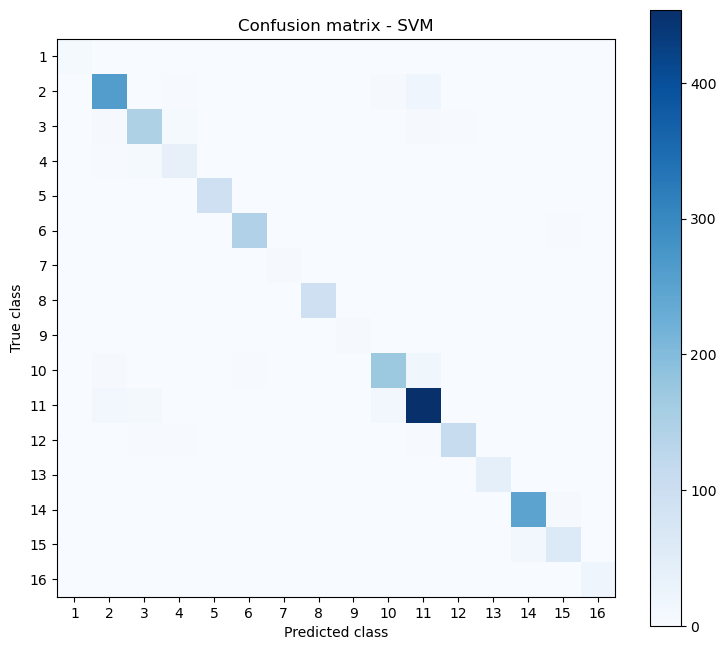

In [18]:
# Step 13: Confusion matrix of the SVM model
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(16), range(1, 17))
plt.yticks(range(16), range(1, 17))
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion matrix - SVM')
plt.show()

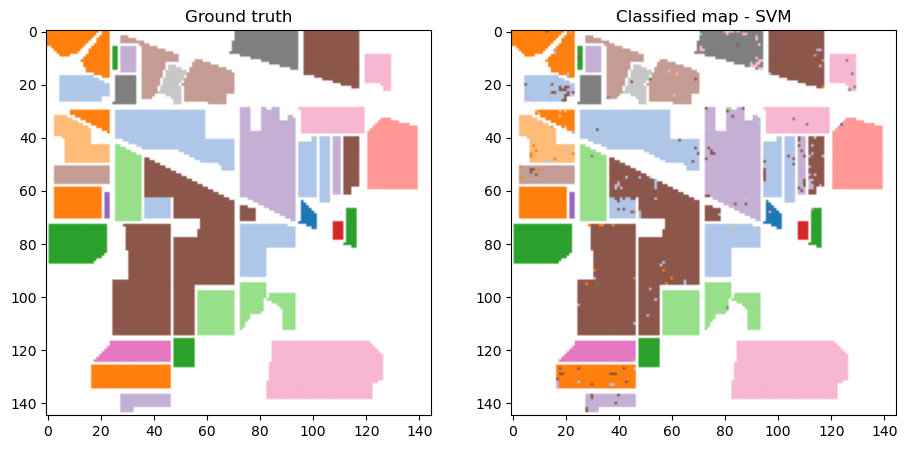

In [20]:
# Step 14: Classified map (predict for the whole image and compare with ground truth)
all_pred = svm.predict(scaler.transform(X_all))
pred_map = all_pred.reshape(gt.shape)

# Show background pixels as 0, same as the ground truth
pred_map[gt == 0] = 0

fig, ax = plt.subplots(1, 2, figsize=(11, 5))

ax[0].imshow(gt, cmap=my_cmap, vmin=0, vmax=16)
ax[0].set_title('Ground truth')

ax[1].imshow(pred_map, cmap=my_cmap, vmin=0, vmax=16)
ax[1].set_title('Classified map - SVM')

plt.show()

In [21]:
# Step 15: Save the results
results.to_csv(r"E:\Projects\India_pine\results_all_bands.csv", index=False)
print("Saved results_all_bands.csv")

Saved results_all_bands.csv
